In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rapidfuzz import fuzz
from nltk import tokenize
import random
import sys
sys.path.insert(0, "../data_extraction")
import search

In [2]:
#Import bertopic
from umap import UMAP
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer

c:\Users\ASUS\Programmation\lhst-the-ecology-of-eucalyptus\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Import and filter metadata
df = pd.read_csv("../data/document_data_clean_filtered.csv")
df_downloaded = df.dropna(subset="ocr_quality").reset_index()
df_downloaded = df_downloaded.set_index("ark")

In [ ]:
def import_text(ark, context, size=50, separated_contexts=True):
    #Keep only paragraphs with "eucalyptus" in them
    if context == "paragraph":
        with open(f"../data/corpus_txt/{ark}.txt", "r", encoding='utf-8') as f:
            text = f.readlines()
        #text = [paragraph for paragraph in text if "eucalyp" in paragraph.lower() or "eucalip" in paragraph.lower() or "encalyp" in paragraph.lower()]
        end_text = [paragraph for paragraph in text if fuzz.token_set_ratio("eucalyptus", paragraph.lower()) > 90]

        #merge contexts through "\n" to have a single text
        #TODO: handle better several occurences?
        end_text = "\n".join(end_text)
        return end_text
    
    #Keep only a certain context window around the word "eucalyptus"
    #TODO: check for handling paragraphs
    #TODO: handle better several occurences (what if eucalyptus is in the context of another?)
    elif context == "context_window":
        with open(f"../data/corpus_txt/{ark}.txt", "r", encoding='utf-8') as f:
            #TODO: check if losing "\n" (paragraph) context is important or not
            text = f.read().split()
        
        #separate text into tokens, get a window of {size} in each side of "eucalyptus"
        tokens_context = []
        for i, word in enumerate(text):
            #if "eucalyp" in word.lower() or "eucalip" in word.lower() or "encalyp" in word.lower():
            if fuzz.ratio("eucalyptus", word.lower()) > 75 or "eucalypt" in word.lower() or "encalypt" in word.lower() or "eucalipt" in word.lower():
                new_text = text[i-size:i] + ["eucalyptus"] + text[i+1:i+size]
                tokens_context.append(new_text)


        #merge text within each occurence, then merge paragraphs with "\n"
        end_text = []
        for context in tokens_context:
            end_text.append(" ".join(context))
            
        if separated_contexts == False:
            end_text = "\n".join(end_text)

        else:
            return end_text

    elif context == "sentence":
        with open(f"../data/corpus_txt/{ark}.txt", "r", encoding='utf-8') as f:
            sentences = tokenize.sent_tokenize(f.read())

        sentence_context = []
        for i, sentence in enumerate(sentences):
            if fuzz.ratio("eucalyptus", sentence.lower()) > 75 or "eucalypt" in sentence.lower() or "encalypt" in sentence.lower() or "eucalipt" in sentence.lower():
                if size == 0:
                    sentence_context.append(sentence)
                else:
                    sentence_context.append(sentences[i-size:i+size])
                    

        #merge text within each occurence, then merge paragraphs with "\n"
        end_text = []
        for context in sentence_context:
            if size != 0:
                end_text.append(" ".join(context))
            else:
                end_text = sentence_context
            
        if separated_contexts == False:
            end_text = "\n".join(end_text)

        else:
            return end_text  

    else:
        raise ValueError('context must be either "paragraph" or "context_window"')

In [ ]:
#import all docs: 
#TODO: Modify context window based on findings from "choose window size"
docs_text = []
docs_ark = []
for doc in df_downloaded.index.to_list():
    text_cleaned = import_text(doc, context="sentence", size=0, separated_contexts=True)
    docs_text.extend(text_cleaned)
    docs_ark.extend([doc] * len(text_cleaned))

## 1) Topic modelling

### 1.0) Choose window size

- Manual verification of 100 samples
- Using topics as verificator

In [54]:
#Create Model
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)
topic_model = BERTopic(ctfidf_model=ctfidf_model, language="multilingual")

In [55]:
context_window_docs = [] 
context_window_topics = []

# phrases
for size in range(0, 4):
    all_docs_text = []
    for doc in df_downloaded["ark"].to_list():
        text_cleaned = import_text(doc, context="sentence", size=size, get_occurrences=False, separated_contexts=True)
        all_docs_text.extend(text_cleaned)
    print(f"added {size} sentence")
    context_window_docs.append(all_docs_text)
    context_window_topics.append(topic_model.fit_transform(all_docs_text))

# context window
for size in range(10, 70, 10):
    all_docs_text = []
    for doc in df_downloaded["ark"].to_list():
        text_cleaned = import_text(doc, context="context_window", size=size, get_occurrences=False, separated_contexts=True)
        all_docs_text.extend(text_cleaned)
    print(f"added {size} context window")
    context_window_docs.append(all_docs_text)
    context_window_topics.append(topic_model.fit_transform(all_docs_text))



KeyboardInterrupt: 

In [38]:
[x[0].count(-1) for x in context_window_topics]

[15278, 17140, 17062, 16097, 16077, 17482, 18808, 18343, 18710, 19511]

In [40]:
samples = random.sample(range(1, len(context_window_docs[0])), 100)
test_samples = [list(map(lambda i: x[i], samples)) for x in context_window_docs]

Si le but c'est de minimizer le nombre de documents dans le topics "-1", il faudrait prendre un context window de 40

In [52]:
pd.DataFrame(test_samples)

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,l'espèce de manne qui suinte en abondance du t...,"également finement pulvérisée, et l'on complèt...","et de quelques gouttes d’éther, tandis que Par...",Charles Granger. Ajoutons encore les belles ag...,"d'une telle substance, dont la pureté n'est pa...",décorateurs connaissent. Les bijoux de M. Vern...,Cassia emarginata. Cassier. Cassia grandis. Ca...,"peut-être, par conséquent, le plus vieux du mo...",cantons rocailleux et les montagnes. « C'est d...,de &^!PPEÏ GUERRE à la TUBERCULOSE par le MIEL...,...,9. ei Le soldat Vatès a essayé aussi quelqll p...,"xanthoréa, les casuarina au feuillage linéaire...","évènement, d’agréer l’hommage de nos sincères ...",maintenant la masquer par l'addition de corps ...,"000 mètres carrés, complanté d orangers, de ci...",les lieux et sont entourées de plantations de ...,sommet couvert de forêts épaisses composées de...,"Pommade Epidermale, Savon des Châtelaines, Sav...",la morphine est indiquée pour la calmer. Le sp...,"passages ei rensslgnsiiieiiis,'s'adresser a RI..."
1,"d'un Exo:, carpus que Bonwick appelle la ceris...","bien pur et finement pulvérisé, on ajoute auta...",a recommandé l’adjonction d’un tiers en poids ...,"Guichard ; dans lile, un groupe d'arum, trades...",fièvres intermittentes légères. Il est certain...,"art perdu, une science que bien peu d'ébéniste...",rung. Beilschmiedia roxburghiana. Chap chai. B...,riches ni plus heureux. — L’arbre le plus gros...,"indi- qué, la Nouvelle -Hollande ou elle vit d...",nde-Rue Iras) Plus de OUXI Phss de ftMUMES I P...,...,"; dindons, 8 ; vérat, 1 ; truIes, petits cocho...",même n’ont pas été visitées sur tout leur déve...,Astier el Conrad Wagenhauser si cruellement ép...,"sa seule odeur, révélatrice il est vrai, mais ...",tlXiWlUIÏitfauborddelamer près de la villa Bro...,habitations appelées estancias sont construite...,"au-dessus du niveau de la mer, et est jusqu'à ...","DROGUERIE. Eau tonique — parachute, de Chalmin...",Une toux trop vive pourrait compromettre la so...,"Janvier. Tanger, Gibraltar. Mutoppo Port-Saïd,..."
2,"arborescentes ; les fruits de certains arbres,...",naturellement faire largement usage. On mélang...,"et au camphre, à la poudre de fève tonka. Gifl...","qui n'est pas sans mérite, c'est le tiburnum-m...",cas d'intolérance de la quinine et dans les ca...,"plus gras, de plus massif; l'art du moulurage ...",ANNAMITES Esse nces de voirie Ardisia crenata....,"colossales, tandis que les ouvriers mineurs n’...",l'a toujours dit. L'espèce babi- te comme nous...,"11, Cours Lafayette . (55,Rue Paut Chenavaro w...",...,"à cornes, 8 ; chèvres, 3 ; moutons» poules, 50...",les tentatives pour la traverser ont été infru...,lieu jeudi matin à dix heures. Nous prions les...,dirions volontiers il est moins dangereux; il ...,Superbe Propriété dite p nUTE-ÀH QT-fli1/ftDfI...,quelques jours de retraite dans la solitude du...,est très-favorable. Le mont Wellington s'élève...,Maison consacrées par un demi-siècle de succès...,du malade. L’immobilité et le silence favorise...,"Trieste, Fiume. Sv. et» ht» n > i — 5 Janvier...."
3,tiges de fougères ordinaires; l'intérieur du t...,"bon état, entre les bains de pied, dont on doi...","menthe, de bergamote. En poudre on l’a mélangé...",Voici une vieille plante qui revient à la mode...,en partie négatives. Laveran conseilla cependa...,"aucune occasion de jouer, quelque chose de plu...",des plantes des pépinières disponüï NOMS SCIEN...,"seront protégées, les compagnies n’en feront p...","le mâle, et non pas de douze seulement, aiusi ...","du buveur. CHAUSSURES COUSUES (65, Rue de la R...",...,23 hectares 90 ares. Il possède en plus : Bêle...,"plusieurs florissantes colonies européennes, e...",a été amenée à Apt où les obsèques ont eu lieu...,"pas meilleur il n'est certes pas plus mauvais,...","pu- î ElLlîf llffl bliques, le iS janvier proc...","au centre de leurs propriétés, où ils viennent...","cultive surtout le houblon, auquel le climat d

In [55]:
with open('test.json', 'w', encoding='utf-8') as file:
    pd.DataFrame(test_samples).to_json(file, index=False, force_ascii=False)

### 1.1) Train the model

In [ ]:
#Train model
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)
umap = UMAP(n_neighbors=15,
            n_components=5,
            min_dist=0.0,
            metric='cosine',
            low_memory=False,
            random_state=1337) 
topic_model = BERTopic(ctfidf_model=ctfidf_model, language="multilingual", umap_model=umap, nr_topics="auto")
topics, probs = topic_model.fit_transform(docs_text)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3334.46it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
#Reduce outliers
new_topics = topic_model.reduce_outliers(docs_text, topics)

In [13]:
#Assign topics to df:
df_downloaded["topics"] = topics

ValueError: Length of values (32592) does not match length of index (9568)

In [9]:
#Assign data to each entry:
docs_type = [df_downloaded.loc[ark, 'type_clean'] for ark in docs_ark]

In [10]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    print(topic_model.get_topic_info())

     Topic  Count                                               Name  \
0       -1  15507                   -1_jardins_oliviers_mer_palmiers   
1        0    942        0_tasmanie_australie_australien_australiens   
2        1    604             1_algérie_algérienne_algériens_tunisie   
3        2    381                                 2_00_38_tanner_260   
4        3    273            3_huiles_essentielle_huile_essentielles   
5        4    264           4_bronchique_gangrène_bronchiques_poumon   
6        5    255        5_malaria_moustiques_paludéennes_paludéenne   
7        6    218                      6_343_formolme_kutschner_1231   
8        7    215              7_circonférence_diamètre_mètres_pieds   
9        8    209                       8_tolu_azotate_soude_bromure   
10       9    199                        9_habit_bouton_nomma_dulcis   
11      10    183                  10_zéro_température_degrés_froids   
12      11    176         11_navales_charpente_charronnage_chauf

In [11]:
topic_document_info_df = topic_model.get_document_info(docs_text)
topic_document_info_df[topic_document_info_df["Representative_document"] == True]

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
3,"Genre de mousse établi par Rphli.ng, qui ne di...",24,24_eucalypti_eucalyptoides_meissn_eucalyptifolium,"[eucalypti, eucalyptoides, meissn, eucalyptifo...","[de H. eucalyptoides (Meissn.)., Hakea eucalyp...",eucalypti - eucalyptoides - meissn - eucalypti...,0.163939,True
4,"nov.\nEUCALYPTUS, Suppl.",97,97_itélépili_hèr_andreana_suppl,"[itélépili, hèr, andreana, suppl, eucaliptus, ...","[EUCALYPTUS, L'hèr., — ITÉLÉPILI\n« EUCALYPTUS...",itélépili - hèr - andreana - suppl - eucaliptu...,0.427770,True
12,ENCALYPTA.,288,288_encalypta_ciliata_encazypt_crispata,"[encalypta, ciliata, encazypt, crispata, sciir...","[Encalypta., ENCALYPTA., Encalypta vulgaris He...",encalypta - ciliata - encazypt - crispata - sc...,1.000000,True
17,Eucalyptus rostrata.,350,350_rostrata_capìtellata_fatigua_versé,"[rostrata, capìtellata, fatigua, versé, incisi...","[Eucalyptus rostrata., » 0 05 Livrables repiqu...",rostrata - capìtellata - fatigua - versé - inc...,1.000000,True
22,"Eucalyptus operculo conìco , -medìo confiriBo ...",209,209_operculo_lateralibus_soliis_folitariis,"[operculo, lateralibus, soliis, folitariis, co...",[Labill.-\nj Eucalyptus operculo c b'asi cór.i...,operculo - lateralibus - soliis - folitariis -...,0.594622,True
...,...,...,...,...,...,...,...,...
32414,"Mais, mon cher collègue, le texte est parfaite...",282,282_desdits_intéressés_devront_communes,"[desdits, intéressés, devront, communes, repré...","[Le département, les communes ou les propriéta...",desdits - intéressés - devront - communes - re...,1.000000,True
32422,"c Le département, les communes ou les propriét...",282,282_desdits_intéressés_devront_communes,"[desdits, intéressés, devront, communes, repré...","[Le département, les communes ou les propriéta...",desdits - intéressés - devront - communes - re...,1.000000,True
32481,L'eucalyptus a été aperçu pour la première foi...,244,244_1792_billardière_pérouse_infortuné,"[1792, billardière, pérouse, infortuné, lapéro...","[Dès 1792, pendant le voyage îles navires la R...",1792 - billardière - pérouse - infortuné - lap...,1.000000,True
32527,Eucalyptol.,81,81_eucalyptol___,"[eucalyptol, , , , , , , , , ]","[Eucalyptol., Eucalyptol ., Eucalyptol.]",eucalyptol - - - - - - - - -,0.039998,True


### 1.2) Model Analysis

In [12]:
cross_tab = pd.DataFrame(columns=["type_clean", "topic"])
cross_tab["type_clean"] = docs_type
cross_tab["topic"] = new_topics

In [13]:
pd.set_option('display.max_columns', 462)
cross_tab = pd.crosstab(cross_tab.type_clean, cross_tab.topic, margins=True)
cross_tab

topic,-1,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,...,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,All
type_clean,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
annuaire,0,4,2,2,0,2,3,0,5,3,0,0,3,1,0,0,0,0,0,1,2,5,0,0,1,3,0,0,0,0,2,7,1,1,1,8,0,0,0,0,7,0,3,1,0,0,0,7,1,0,0,0,3,0,0,0,0,0,6,0,1,0,0,0,0,0,1,0,1,1,1,0,0,3,1,0,0,0,0,0,0,0,2,1,0,0,0,0,0,0,0,0,3,0,0,0,0,1,2,0,3,0,0,5,0,0,1,1,0,0,1,0,2,1,0,0,0,0,0,0,0,1,1,0,0,0,0,2,2,18,1,1,0,2,1,0,0,0,0,0,2,0,0,1,0,0,0,0,0,0,0,0,3,0,2,1,0,0,0,0,0,0,0,2,0,2,4,0,2,0,0,0,0,0,0,2,0,0,0,0,0,5,1,1,0,0,0,1,0,0,0,0,0,0,0,0,3,18,0,0,0,1,1,0,2,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,2,3,0,0,1,0,0,0,0,0,4,...,1,0,0,0,0,0,0,2,1,4,10,0,0,6,1,0,0,4,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,3,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,2,0,0,0,0,1,1,41,0,1,0,0,0,0,2,0,0,0,0,1,0,12,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,4,2,0,0,0,0,11,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,4,0,0,0,2,0,2,1,0,1,0,0,0,1,1,0,0,0,0,0,2,0,0,0,0,0,6,0,0,0,20,0,0,0,0,1,0,0,3,1,0,1,0,0,0,0,0,0,0,0,1,0,20,0,2,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,16,0,0,0,0,1,0,1,0,0,1,0,0,0,3,0,0,0,0,0,0,2,0,0,0,1,435
monographie,6,526,257,174,125,179,134,135,151,155,91,124,97,85,74,50,90,123,47,104,73,34,54,55,45,64,63,48,35,91,143,11,12,21,31,2,62,34,20,29,46,1,44,36,2,26,60,35,42,7,41,51,42,2,75,35,35,16,20,3,24,88,80,13,24,0,36,47,53,40,37,54,41,7,32,44,11,25,40,41,36,2,165,42,22,50,1,50,4,21,31,4,53,14,11,2,23,52,43,7,4,2,28,112,50,38,1,2,23,18,0,23,22,38,17,16,1,13,9,5,66,23,29,19,33,48,36,23,4,11,1,19,17,14,2,37,10,26,36,9,43,8,15,10,49,23,16,3,0,14,25,9,12,3,18,12,34,7,22,14,88,26,9,11,23,1,2,38,24,4,0,12,10,16,14,36,3,1,24,16,22,23,25,5,24,3,23,38,21,0,30,29,12,15,28,20,4,5,7,11,28,32,20,21,15,20,29,15,18,20,26,17,16,25,115,29,48,8,3,1,26,10,13,26,45,9,15,7,18,22,9,...,12,18,30,9,27,0,1,9,16,34,18,11,42,3,52,32,0,13,18,7,25,14,62,41,12,11,3,5,10,87,21,19,46,19,1,6,7,41,10,3,1,4,5,0,20,1,22,30,29,3,0,41,3,45,72,22,16,29,24,16

In [14]:
topic_number = 18
print(f"Topic: {topic_number}")
topic_model.get_topic(topic_number)

Topic: 18


[('villa', np.float64(0.18731140199849128)),
 ('colline', np.float64(0.17549292476629919)),
 ('palais', np.float64(0.16844928524667302)),
 ('château', np.float64(0.16844928524667302)),
 ('hôtel', np.float64(0.16112379713783084)),
 ('terrasses', np.float64(0.1536072426067004)),
 ('ermitage', np.float64(0.1509439551150085)),
 ('hôtels', np.float64(0.1500809742943041)),
 ('villas', np.float64(0.14603407721730952)),
 ('tanger', np.float64(0.14556109254138727))]

## 2) Occurences

In [21]:
def get_occurrences(ark, target="eucalyptus", ratio=75):
    with open(f"../data/corpus_txt/{ark}.txt", "r", encoding='utf-8') as f:
        text = f.read().split()

    if type(target) is not list:
        occurrences = 0
        for word in text:
            if target == "eucalyptus":
                if fuzz.ratio("eucalyptus", word.lower()) > ratio or "eucalypt" in word.lower() or "encalypt" in word.lower() or "eucalipt" in word.lower():
                    occurrences += 1
            else:
                if fuzz.ratio(target, word.lower()) > ratio or target in word.lower():
                    occurrences += 1
        
        return occurrences

    else:
        occurrences_list = [0 for x in target]
        for word in text:
            for i, word_target in enumerate(target):
                if word_target == "eucalyptus":
                    if fuzz.ratio("eucalyptus", word.lower()) > ratio or "eucalypt" in word.lower() or "encalypt" in word.lower() or "eucalipt" in word.lower():
                        occurrences_list[i] += 1
                else:
                    if fuzz.ratio(word_target, word.lower()) > ratio or word_target in word.lower():
                        occurrences_list[i] += 1
    
        return occurrences_list

In [ ]:
docs_occurrences = []
for doc in df_downloaded.index.to_list():
    docs_occurrences.append(get_occurrences(doc))

In [42]:
df_downloaded["occurences"] = docs_occurrences

In [43]:
df_downloaded.groupby("type_clean")["occurences"].describe()

,count,mean,std,min,25%,50%,75%,max
type_clean,,,,,,,,
annuaire,105.0,4.961905,13.794455,1.0,1.0,1.0,3.0,113.0
monographie,2437.0,5.447271,18.829876,1.0,1.0,2.0,4.0,506.0
presse généraliste,4451.0,2.001348,3.694940,1.0,1.0,1.0,2.0,138.0
presse officielle,765.0,2.342484,3.081839,1.0,1.0,1.0,2.0,39.0
presse spécialisée,1805.0,6.374515,21.786517,1.0,1.0,2.0,4.0,450.0


In [45]:
df_downloaded.sort_values(by="occurences", ascending=False)[["occurences", "title_clean", "date_clean", "author_name_clean", "type_clean"]].head(15)

,occurences,title_clean,date_clean,author_name_clean,type_clean
ark,,,,,
bpt6k9395289,506,"Les eucalyptus, aire géographique de leur indi...",1888.0,"Sahut, Félix",monographie
bpt6k5450469q,450,Bulletin de la Société d'acclimatation,1872.0,Société nationale de protection de la nature (...,presse spécialisée
bpt6k1193756m,400,L'eucalyptus et ses dérivés,1898.0,"Combes, Paul",monographie
bpt6k6124497x,320,Bulletin de la Société d'acclimatation,1873.0,Société nationale de protection de la nature (...,presse spécialisée
bpt6k934417w,289,L'eucalyptus,1875.0,"Raveret-Wattel, Casimir",monographie
bd6t54341550j,275,La Médecine moderne,1894.0,NaN,presse spécialisée
bpt6k6138375h,267,"L'""Eucalyptus globulus"", son importance en agr...",1870.0,"Gimbert, Dr (de Cannes)",monographie
bpt6k871970s,266,L'eucalyptus et ses applications industrielles,1877.0,"Martin, Félix (ingénieur des Ponts et chaussées)",monographie
bpt6k5450404c,252,Bulletin de la Société d'acclimatation,1875.0,Société nationale de protection de la nature (...,presse spécialisée


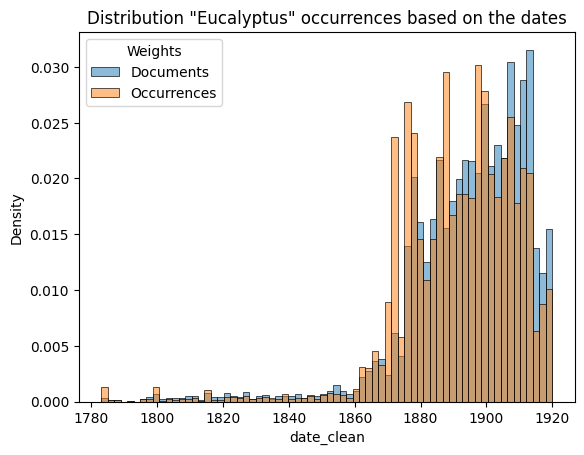

In [77]:
sns.histplot(df_downloaded, x="date_clean", bins=70, stat="density", label='Documents', alpha=0.5)
sns.histplot(df_downloaded, x="date_clean", weights="occurences", bins=70, stat="density", label='Occurrences', alpha=0.5)
plt.legend(title= "Weights", loc= "upper left")
plt.title('Distribution "Eucalyptus" occurrences based on the dates')
plt.show()

### 2.2) Occurences type eucalyptus

In [9]:
#From Robin W. Doughty, "The Eucalyptus, A Natural and Commercial History of the Gum Tree", p.181-187
dict_occurrences_type = {
    "botryoides": [],
    "camaldulensis": [], 
    "citriodora": [],
    "deglupta": [],
    "globulus": [],
    "grandis": [],
    "obliqua": [],
    "regnans": [],
    "saligna": [],
    "tereticornis": [],
    "urophylla": [],
    "viminalis": []
}

In [24]:
#TODO: modify "get_occurrences" in order to take a list of words and send a dict of the number of occurrences for each type
for j, doc in enumerate(df_downloaded.index.to_list()):
    docs_occurrences = get_occurrences(doc, target=list(dict_occurrences_type.keys()), ratio=80)
    for i, key in enumerate(dict_occurrences_type.keys()):
        dict_occurrences_type[key].append(docs_occurrences[i])
     
    if j % 100 == 0:
        print(f"{j} documents processed")

for type in dict_occurrences_type.keys():
    df_downloaded[f"occurences_{type}"] = dict_occurrences_type[type]

0 documents processed
100 documents processed
200 documents processed
300 documents processed
400 documents processed
500 documents processed
600 documents processed
700 documents processed
800 documents processed
900 documents processed
1000 documents processed
1100 documents processed
1200 documents processed
1300 documents processed
1400 documents processed
1500 documents processed
1600 documents processed
1700 documents processed
1800 documents processed
1900 documents processed
2000 documents processed
2100 documents processed
2200 documents processed
2300 documents processed
2400 documents processed
2500 documents processed
2600 documents processed
2700 documents processed
2800 documents processed
2900 documents processed
3000 documents processed
3100 documents processed
3200 documents processed
3300 documents processed
3400 documents processed
3500 documents processed
3600 documents processed
3700 documents processed
3800 documents processed
3900 documents processed
4000 documen

ValueError: Length of values (9571) does not match length of index (9563)

In [110]:
df_downloaded.groupby("type_clean")["occurences_globulus"].describe()

,count,mean,std,min,25%,50%,75%,max
type_clean,,,,,,,,
annuaire,105.0,0.095238,0.404870,0.0,0.0,0.0,0.0,3.0
monographie,2437.0,0.502667,3.193103,0.0,0.0,0.0,0.0,75.0
presse généraliste,4451.0,0.108740,0.742811,0.0,0.0,0.0,0.0,31.0
presse officielle,765.0,0.098039,0.471223,0.0,0.0,0.0,0.0,7.0
presse spécialisée,1805.0,0.633795,3.646289,0.0,0.0,0.0,0.0,72.0


In [111]:
df_downloaded.sort_values(by="occurences_globulus", ascending=False)[["occurences_globulus", "title_clean", "date_clean", "author_name_clean", "type_clean"]].head(15)

,occurences_globulus,title_clean,date_clean,author_name_clean,type_clean
ark,,,,,
bpt6k934417w,75,L'eucalyptus,1875.0,"Raveret-Wattel, Casimir",monographie
bpt6k5450469q,72,Bulletin de la Société d'acclimatation,1872.0,Société nationale de protection de la nature (...,presse spécialisée
bpt6k871970s,65,L'eucalyptus et ses applications industrielles,1877.0,"Martin, Félix (ingénieur des Ponts et chaussées)",monographie
bpt6k6124497x,64,Bulletin de la Société d'acclimatation,1873.0,Société nationale de protection de la nature (...,presse spécialisée
bpt6k5450404c,60,Bulletin de la Société d'acclimatation,1875.0,Société nationale de protection de la nature (...,presse spécialisée
bpt6k9395289,60,"Les eucalyptus, aire géographique de leur indi...",1888.0,"Sahut, Félix",monographie
bpt6k5453845m,55,Bulletin de la Société d'acclimatation,1877.0,Société nationale de protection de la nature (...,presse spécialisée
bpt6k6138375h,54,"L'""Eucalyptus globulus"", son importance en agr...",1870.0,"Gimbert, Dr (de Cannes)",monographie
bpt6k1193756m,44,L'eucalyptus et ses dérivés,1898.0,"Combes, Paul",monographie


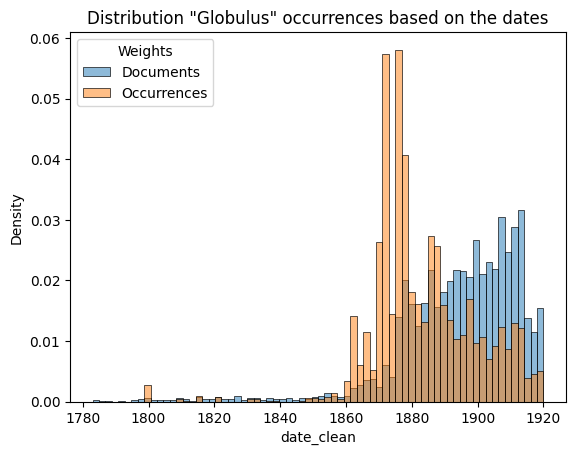

In [112]:
sns.histplot(df_downloaded, x="date_clean", bins=70, stat="density", label='Documents', alpha=0.5)
sns.histplot(df_downloaded, x="date_clean", weights="occurences_globulus", bins=70, stat="density", label='Occurrences', alpha=0.5)
plt.legend(title= "Weights", loc= "upper left")
plt.title('Distribution "Globulus" occurrences based on the dates')
plt.show()

## 3) Distributions

In [3]:
df = pd.read_csv("../data/merged_df_filtered.csv")

### 3.1) Date

<Axes: title={'center': 'Date Distribution'}, xlabel='date_clean', ylabel='Count'>

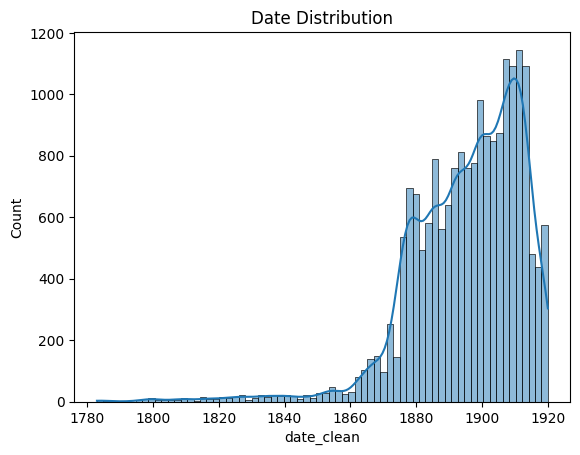

In [4]:
# 1 bin ~= 2 year
plt.title("Date Distribution")
sns.histplot(df, x="date_clean", bins=70, kde=True)

<Axes: title={'center': 'Date Distribution per type of publication'}, xlabel='date_clean', ylabel='Count'>

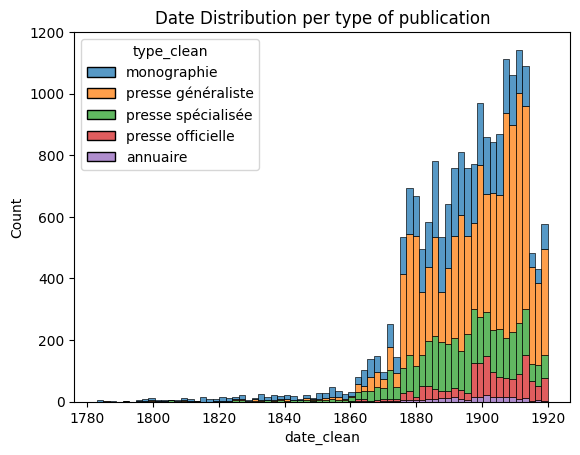

In [80]:
plt.title("Date Distribution per type of publication")
sns.histplot(df, x="date_clean", bins=70, hue="type_clean", multiple="stack")

<Axes: title={'center': 'Date Distribution per type of author'}, xlabel='date_clean', ylabel='Count'>

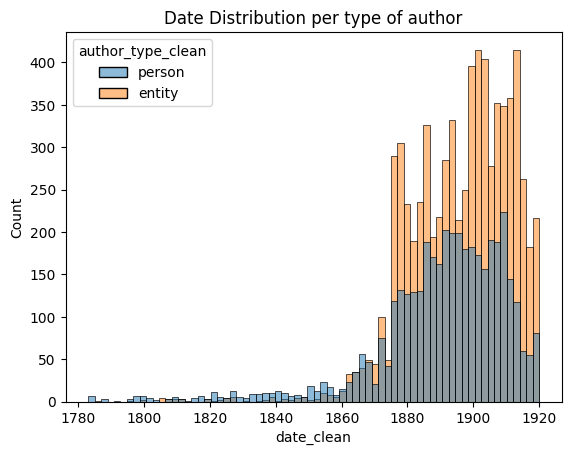

In [81]:
plt.title("Date Distribution per type of author")
sns.histplot(df, x="date_clean", bins=70, hue="author_type_clean")

<Axes: title={'center': 'Date Distribution per publishing place'}, xlabel='date_clean', ylabel='Count'>

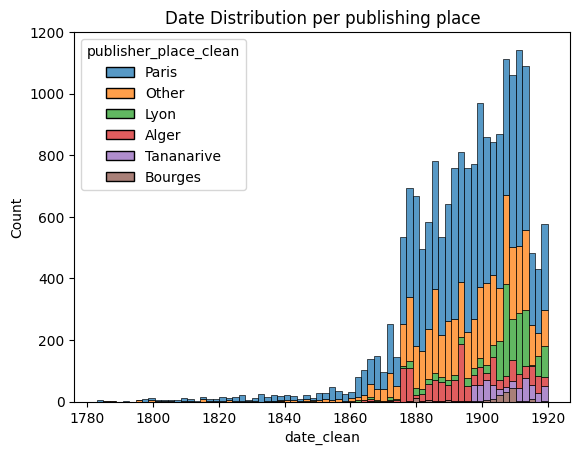

In [82]:
plt.title("Date Distribution per publishing place")
place = [place if place in ["Paris", "Lyon", "Alger", "Tananarive", "Bourges"] else "Other" for place in df["publisher_place_clean"].to_list()]
new_df = df.copy()
new_df["publisher_place_clean"] = place
sns.histplot(new_df, x="date_clean", bins=70, hue="publisher_place_clean", multiple="stack")

### 3.2) Counts

In [83]:
df["publisher_place_clean"].value_counts().head(10)

publisher_place_clean
Paris          10854
Lyon            1459
Alger           1374
Tananarive       508
Bourges          170
Marseille        169
Hyères           150
Toulouse         143
Orléans          143
Montpellier      121
Name: count, dtype: int64

In [84]:
df["type_clean"].value_counts().head(10)

type_clean
presse généraliste    9512
monographie           4418
presse spécialisée    3466
presse officielle     1369
annuaire               239
Name: count, dtype: int64

In [85]:
df["author_type_clean"].value_counts()

author_type_clean
entity    7143
person    4107
Name: count, dtype: int64

# Gallica date distribution

In [3]:
tot_documents = []
for year in range(1780, 1920):
    #time.sleep(15)
    query = f'dc.date = "{year}" sortby dc.date/sort.descending'
    doc = search.single_search_gallica(query, startRecord=0)
    try:
        tot_documents.append(int(doc.find("srw:numberofrecords").text.strip()))
    except:
        print(year)
        print(doc)
        tot_documents.append(0)

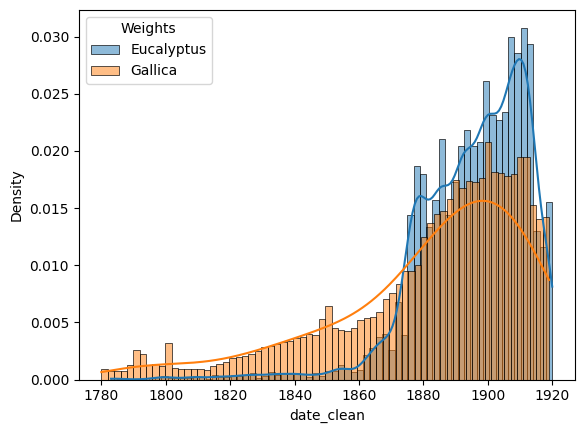

In [6]:
df_gallica_docs = pd.DataFrame()
df_gallica_docs["year"] = range(1780, 1920)
df_gallica_docs["docs"] = tot_documents
sns.histplot(df, x="date_clean", bins=70, kde=True, stat="density", label="Eucalyptus", alpha=0.5)
sns.histplot(df_gallica_docs, x=df_gallica_docs["year"], weights=df_gallica_docs["docs"], bins=70, kde=True, label="Gallica", stat="density", alpha=0.5)
plt.legend(title= "Weights", loc= "upper left")

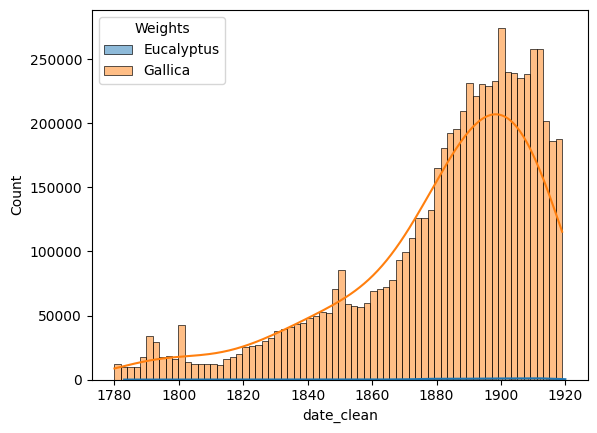

In [8]:
sns.histplot(df, x="date_clean", bins=70, kde=True, label="Eucalyptus", alpha=0.5)
sns.histplot(df_gallica_docs, x=df_gallica_docs["year"], weights=df_gallica_docs["docs"], bins=70, kde=True, label="Gallica", alpha=0.5)
plt.legend(title= "Weights", loc= "upper left")

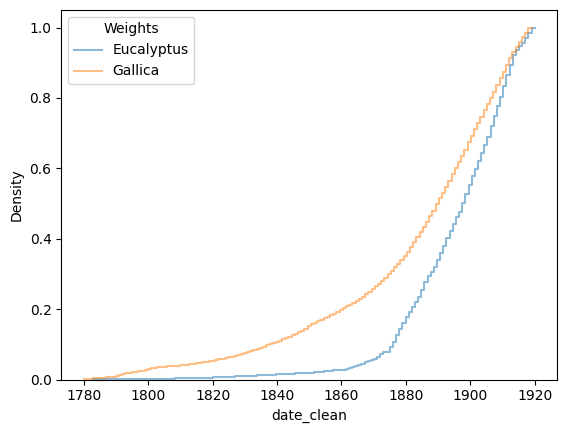

In [7]:
sns.histplot(df, x="date_clean", bins=140, cumulative=True, stat="density", element="step", fill=False, label="Eucalyptus", alpha=0.5)
sns.histplot(df_gallica_docs, x=df_gallica_docs["year"], weights=df_gallica_docs["docs"], bins=140, element="step", fill=False, cumulative=True, label="Gallica", stat="density", alpha=0.5)
plt.legend(title= "Weights", loc= "upper left")

# OTHER
